In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
amazon = pd.read_csv('visualizations 2/datasets/amazon.csv')

In [4]:
amazon.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2008-12-08,49.150002,52.139999,47.360001,51.410000,51.410000,10940700
1,2008-12-09,49.810001,54.480000,49.700001,51.250000,51.250000,13314800
2,2008-12-10,51.459999,51.500000,48.340000,49.700001,49.700001,7753800
3,2008-12-11,49.330002,50.490002,48.169998,48.250000,48.250000,7583600
4,2008-12-12,47.520000,51.380001,47.520000,51.250000,51.250000,8664800


In [5]:
amazon.index = pd.to_datetime(amazon['Date'])

In [9]:
amazon = amazon.drop('Date',axis=1)

In [12]:
amazon.index

DatetimeIndex(['2008-12-08', '2008-12-09', '2008-12-10', '2008-12-11',
               '2008-12-12', '2008-12-15', '2008-12-16', '2008-12-17',
               '2008-12-18', '2008-12-19',
               ...
               '2018-11-21', '2018-11-23', '2018-11-26', '2018-11-27',
               '2018-11-28', '2018-11-29', '2018-11-30', '2018-12-03',
               '2018-12-04', '2018-12-06'],
              dtype='datetime64[us]', name='Date', length=2517, freq=None)

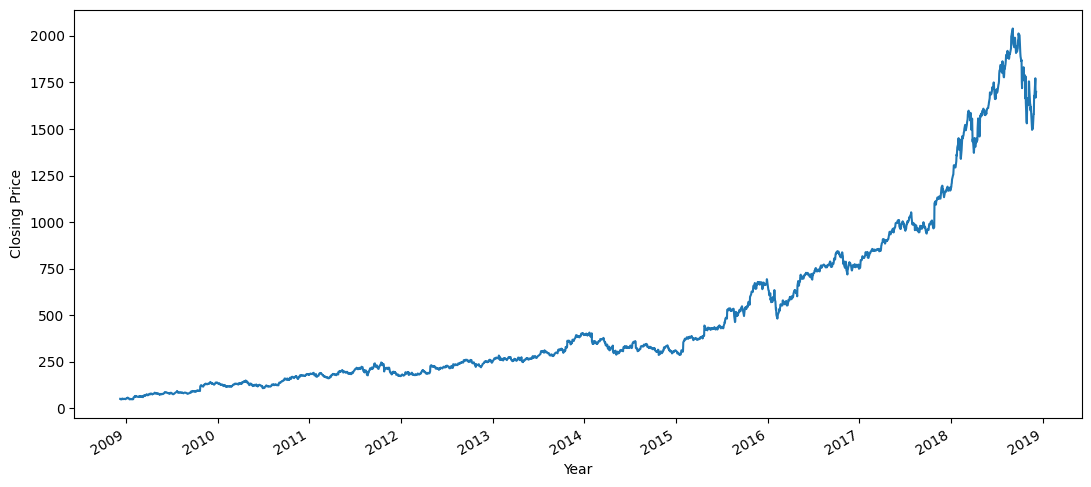

In [13]:
amazon['Adj Close'].plot(kind='line',figsize=(13,6))
plt.ylabel('Closing Price')
plt.xlabel('Year')
plt.show()

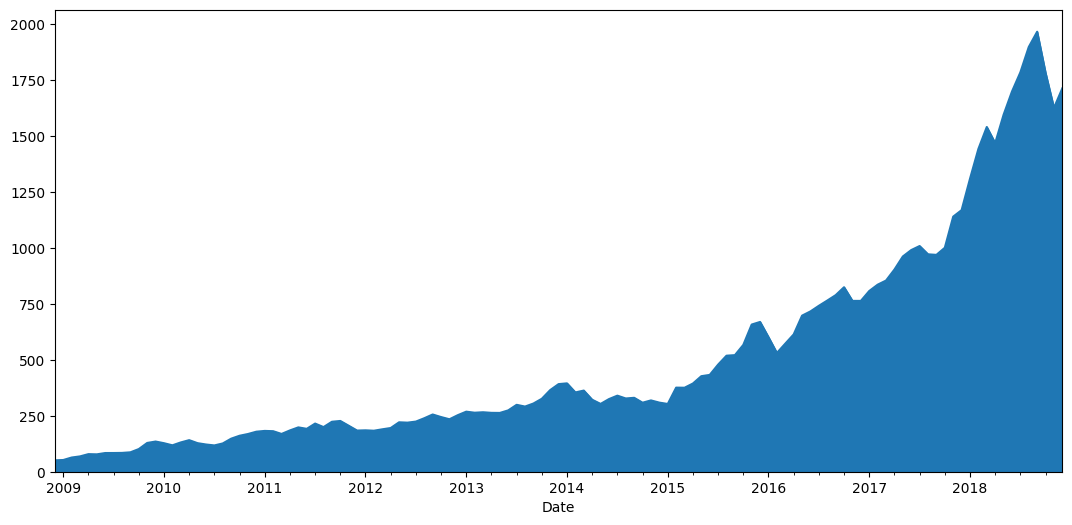

In [22]:
adj_month = amazon['Adj Close'].resample('ME').mean()
adj_month.plot(kind='area',figsize=(13,6))
plt.show()

In [30]:
amazon['Adj Close'].diff().rolling(window=5).mean().head(10)
amazon['Adj Close'].pct_change().rolling(window=5).std().head(10)

Date
2008-12-08         NaN
2008-12-09         NaN
2008-12-10         NaN
2008-12-11         NaN
2008-12-12         NaN
2008-12-15    0.042980
2008-12-16    0.058289
2008-12-17    0.054570
2008-12-18    0.052968
2008-12-19    0.046894
Name: Adj Close, dtype: float64

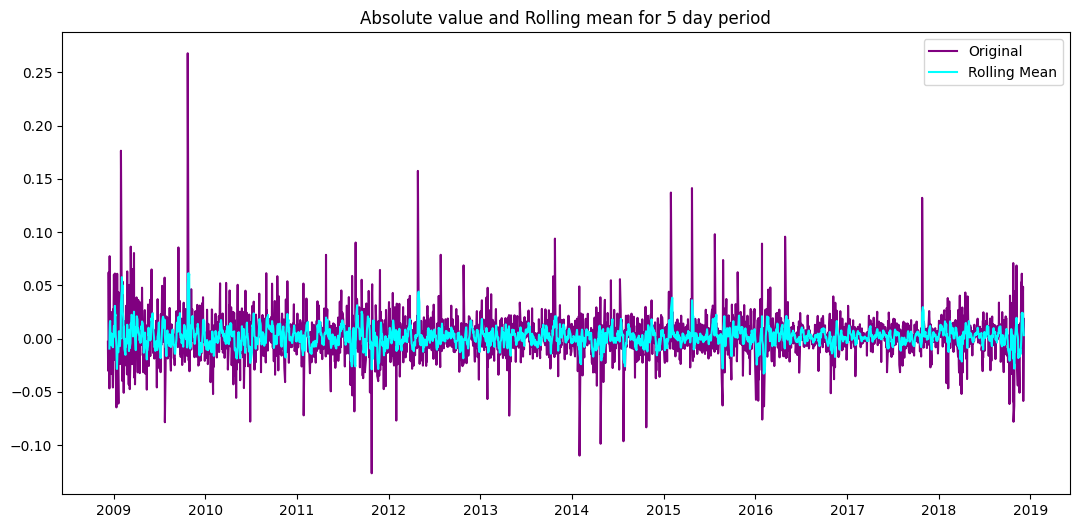

In [33]:
fig = plt.figure(figsize=(13,6))
original = plt.plot(amazon['Adj Close'].pct_change(),color="purple",label="Original")
mean = plt.plot(amazon['Adj Close'].pct_change().rolling(window=5).mean(),color="cyan",label="Rolling Mean")
plt.legend(loc='best')
plt.title("Absolute value and Rolling mean for 5 day period")
plt.show()

In [34]:
pd.Timestamp('20/09/2018')

Timestamp('2018-09-20 00:00:00')

In [35]:
pd.Timestamp(45678910,unit='s')

Timestamp('1971-06-13 16:35:10')

In [37]:
pd.date_range('9:00',"14:00",freq='30min').time

array([datetime.time(9, 0), datetime.time(9, 30), datetime.time(10, 0),
       datetime.time(10, 30), datetime.time(11, 0), datetime.time(11, 30),
       datetime.time(12, 0), datetime.time(12, 30), datetime.time(13, 0),
       datetime.time(13, 30), datetime.time(14, 0)], dtype=object)

In [39]:
pd.Timedelta('1day 1hour 1min 1sec')

Timedelta('1 days 01:01:01')

In [40]:
pd.Timestamp('20/09/2018') + pd.Timedelta('1day 1hour 1min 1sec')

Timestamp('2018-09-21 01:01:01')

In [48]:
td = pd.Series([pd.Timedelta(days = i,hours=9) for i in range(3)])
td

0   0 days 09:00:00
1   1 days 09:00:00
2   2 days 09:00:00
dtype: timedelta64[us]

In [52]:
days = pd.Series(pd.date_range('20/09/2018',periods=3,freq='D'))
delta_range = pd.DataFrame(dict(days = days, delta = td))
delta_range

,days,delta
0,2018-09-20,0 days 09:00:00
1,2018-09-21,1 days 09:00:00
2,2018-09-22,2 days 09:00:00
